Importing important libraries

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix 

Loading The Dataset

In [3]:
iris=fetch_ucirepo(id=53)
X=iris.data.features
Y=iris.data.targets

Exploratory Data Analysis

In [4]:
X.dtypes

sepal length    float64
sepal width     float64
petal length    float64
petal width     float64
dtype: object

In [5]:
X.shape

(150, 4)

In [6]:
X.head(5)

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
Y.head(5)

,class
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [8]:
df = pd.concat([X, Y], axis=1)
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [10]:
df.describe()

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [11]:
df.isnull().sum()

sepal length    0
sepal width     0
petal length    0
petal width     0
class           0
dtype: int64

### Encoding the Target Variable

- We use `LabelEncoder` to convert the categorical target variable `Y` into numeric labels.  
- `Y_encoded` contains the encoded numerical values corresponding to each category in `Y`.  
- `unique_labels` lists all unique original labels present in `Y` before encoding.  

This is useful to understand the mapping between the original categories and their numeric representation.


In [12]:
le=LabelEncoder()
Y_encoded=le.fit_transform(Y)
unique_labels=list(set(Y.to_numpy().reshape(-1).tolist()))
# unique_labels
unique_labels

C:\Users\Samsung\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


['Iris-setosa', 'Iris-virginica', 'Iris-versicolor']

In [13]:
Y_encoded

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [14]:
combinations = list(itertools.combinations(X.columns, 2))

### Generating Pairwise Feature Combinations

- We use `itertools.combinations` to create all possible **pairs of features** from `X.columns`.  
- `combinations` will contain a list of tuples, where each tuple is a pair of feature names.  
- This is often useful for **feature interaction analysis** or **pairwise plotting**.


Plotting 6 graphs

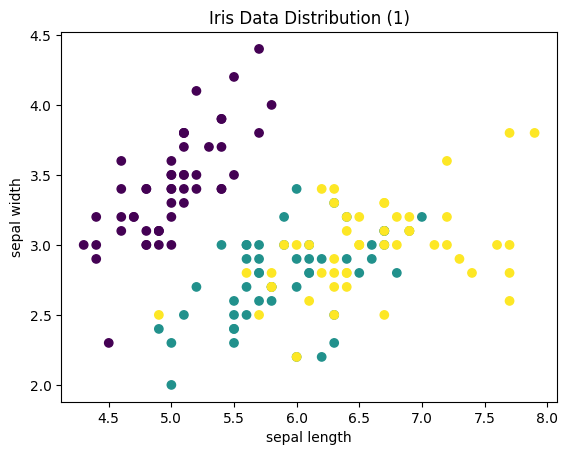

In [15]:
plt.scatter(X[combinations[0][0]], X[combinations[0][1]], c=Y_encoded)
plt.xlabel(combinations[0][0])
plt.ylabel(combinations[0][1])
plt.title("Iris Data Distribution (1)")
plt.show()


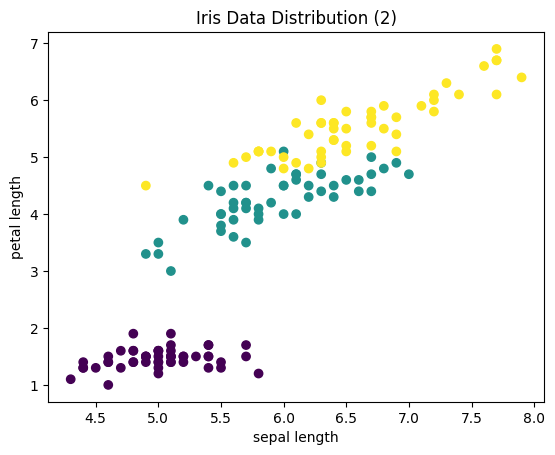

In [16]:
plt.scatter(X[combinations[1][0]], X[combinations[1][1]], c=Y_encoded)
plt.xlabel(combinations[1][0])
plt.ylabel(combinations[1][1])
plt.title("Iris Data Distribution (2)")
plt.show()


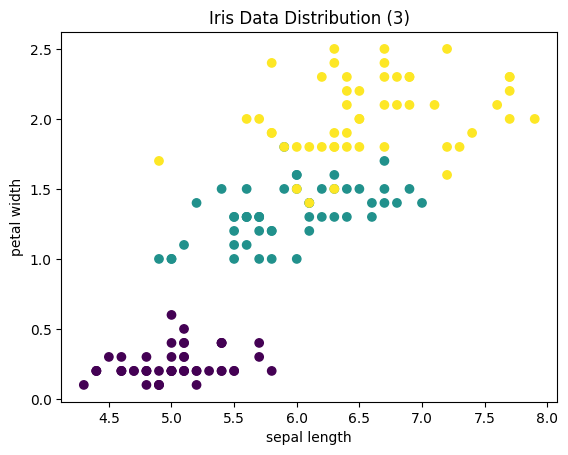

In [17]:
plt.scatter(X[combinations[2][0]], X[combinations[2][1]], c=Y_encoded)
plt.xlabel(combinations[2][0])
plt.ylabel(combinations[2][1])
plt.title("Iris Data Distribution (3)")
plt.show()


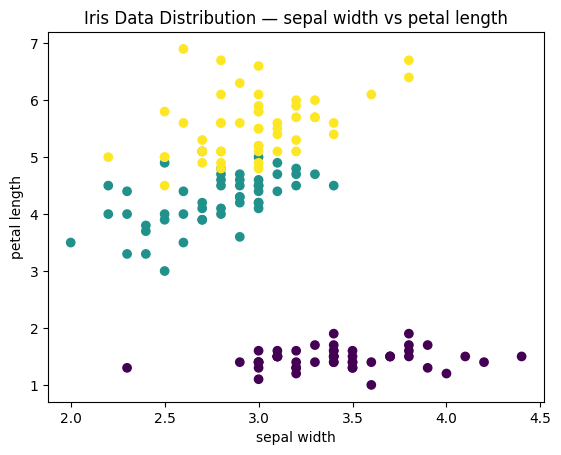

In [18]:
plt.scatter(X[combinations[3][0]], X[combinations[3][1]], c=Y_encoded)
plt.xlabel(combinations[3][0])
plt.ylabel(combinations[3][1])
plt.title(f"Iris Data Distribution — {combinations[3][0]} vs {combinations[3][1]}")
plt.show()


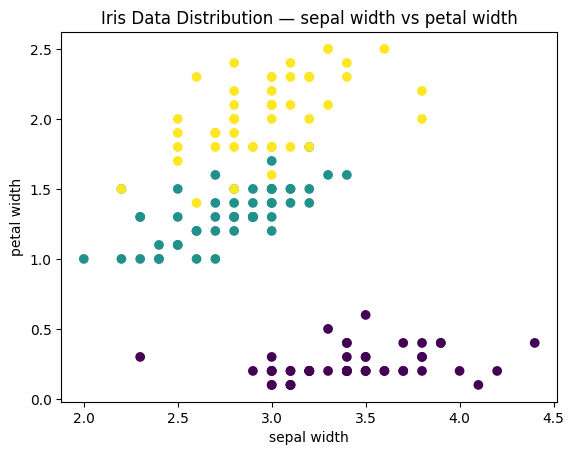

In [19]:
plt.scatter(X[combinations[4][0]], X[combinations[4][1]], c=Y_encoded)
plt.xlabel(combinations[4][0])
plt.ylabel(combinations[4][1])
plt.title(f"Iris Data Distribution — {combinations[4][0]} vs {combinations[4][1]}")
plt.show()


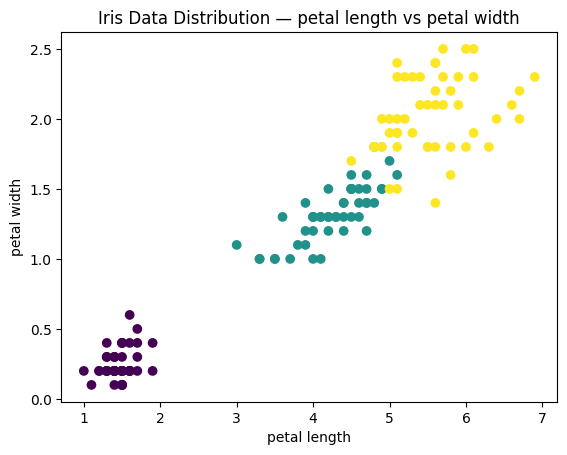

In [20]:
plt.scatter(X[combinations[5][0]], X[combinations[5][1]], c=Y_encoded)
plt.xlabel(combinations[5][0])
plt.ylabel(combinations[5][1])
plt.title(f"Iris Data Distribution — {combinations[5][0]} vs {combinations[5][1]}")
plt.show()


### Custom Train-Test Split Function

- This function splits the dataset into training and testing sets **without using scikit-learn**.  
- **Parameters:**
  - `random_state` : Integer seed for reproducibility of shuffling.  
  - `train_split` : Fraction of data to use for training (e.g., 0.8 for 80%).  
  - `X` : Feature DataFrame.  
  - `Y` : Target Series or DataFrame.  
- **Process:**
  1. Shuffle the dataset using `np.random.permutation`.  
  2. Split `X` and `Y` into training and testing sets according to `train_split`.  
  3. Print shapes of `X_train` and `X_test`.  
- **Returns:** `X_train`, `X_test`, `Y_train`, `Y_test`.  

This function gives the same functionality as `sklearn.model_selection.train_test_split` but implemented manually for learning purposes.


In [21]:
def train_test_split(random_state:int,train_split:float,X:pd.DataFrame,Y:pd.DataFrame):
    np.random.seed(random_state)
    perm = np.random.permutation(len(X))
    X=X.iloc[perm]
    Y=Y[perm]
    
    split_idx = int(train_split * len(X))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    Y_train, Y_test = Y[:split_idx], Y[split_idx:]
    print(X_train.shape,X_test.shape)
    
    return X_train,X_test,Y_train,Y_test

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_encoded, test_size=0.15, random_state=42
)


### Custom K-Nearest Neighbors (KNN) Class

- This class implements the **KNN algorithm from scratch** for classification.  

**Components:**
1. `__init__(train_x, train_y)`  
   - Stores the training features `train_x` and labels `train_y`.  

2. `predict(X, k)`  
   - Converts `X` to a NumPy array.  
   - Computes the **Euclidean distance** between each test point and all training points using vectorized operations.  
   - Finds the indices of the `k` nearest neighbors (`neighbors_idx`).  
   - Gathers the labels of the nearest neighbors and selects the most frequent label (`np.bincount().argmax()`) as the prediction.  
- Returns `y_pred`, the predicted labels for all test samples.  

This implementation demonstrates a fully **vectorized and efficient approach** without using scikit-learn.


In [36]:
class KNN:
    def __init__(self, train_x: pd.DataFrame, train_y):
        # Convert everything to NumPy arrays for consistency
        self.train_x = train_x.to_numpy() if isinstance(train_x, pd.DataFrame) else train_x
        self.train_y = train_y.to_numpy().ravel() if isinstance(train_y, (pd.DataFrame, pd.Series)) else train_y.ravel()
        
    def predict(self, X: pd.DataFrame, k: int):
        X = X.to_numpy() if isinstance(X, pd.DataFrame) else X
        
        # Euclidean distance calculation (vectorized)
        dists = np.sqrt(
            np.expand_dims(np.sum(X**2, axis=1), axis=-1)
            + np.expand_dims(np.sum(self.train_x**2, axis=1), axis=0)
            - 2 * np.dot(X, self.train_x.T)
        )
        
        neighbors_idx = np.argsort(dists, axis=1)[:, :k]  # indices of k nearest neighbors
        
        # Get neighbor labels safely
        y_pred = []
        for idx_row in neighbors_idx:
            neighbor_labels = self.train_y[idx_row]  # always 1D array
            most_common = np.bincount(neighbor_labels).argmax()
            y_pred.append(most_common)
        
        return np.array(y_pred)


In [37]:
classifier=KNN(X_train,Y_train)

### Evaluating KNN with Different Values of k

- We test the KNN classifier for multiple values of `k`: `[3, 5, 7, 9, 11, 15]`.  
- For each `k`:
  1. Predict labels on the test set using `classifier.predict(X_test, k)`.  
  2. Compute the **confusion matrix** using `confusion_matrix`.  
  3. Display the confusion matrix with `ConfusionMatrixDisplay`, showing **true vs predicted labels**.  
  4. Calculate the **accuracy** as the fraction of correct predictions.  
  5. Set the subplot title to show `k` and the corresponding accuracy.  
- `accuracies` stores the accuracy for each `k`, allowing comparison of classifier performance for different neighbor counts.  
- `plt.subplots` and `axes` are used to neatly plot multiple confusion matrices vertically for easy visualization.


6


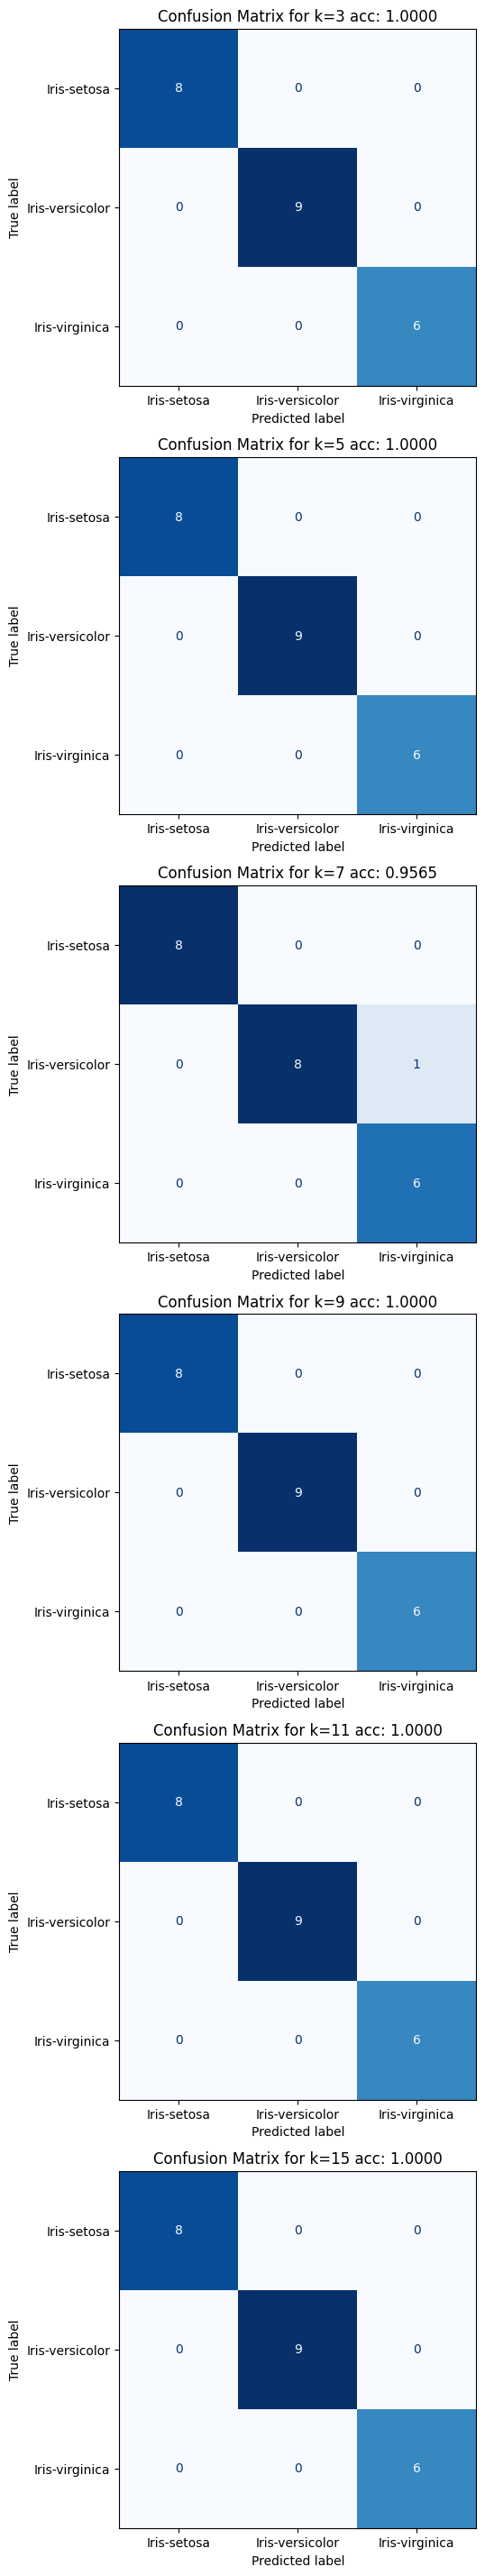

In [38]:
ks=[3,5,7,9,11,15]

fig, axes = plt.subplots(len(ks), 1, figsize=(12, 36))

accuracies=[]
for i,k in enumerate(ks):

    plt.subplot(len(ks),1,i+1)
    predictions=classifier.predict(X_test,k)
    cm=confusion_matrix(Y_test,predictions)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues", values_format="d", ax=axes[i], colorbar=False)
    acc=(predictions==Y_test).sum()/Y_test.shape[0]
    axes[i].set_title(f"Confusion Matrix for k={k} acc: {acc:.4f}")
    accuracies.append(acc)
print(len(accuracies))
plt.show()

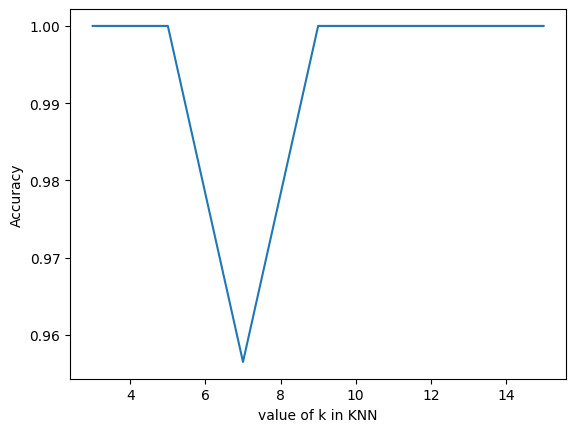

In [39]:
plt.plot(ks,accuracies)
plt.xlabel("value of k in KNN")
plt.ylabel("Accuracy")
plt.show()

In [40]:
#wine dataset
iris=fetch_ucirepo(id=109)
X_wine=iris.data.features
Y_wine=iris.data.targets

le_wine=LabelEncoder()
Y_wine_encoded=le_wine.fit_transform(Y_wine)

C:\Users\Samsung\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [41]:
X_wine.head(5)

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [42]:
Y_wine.head()

,class
0,1
1,1
2,1
3,1
4,1


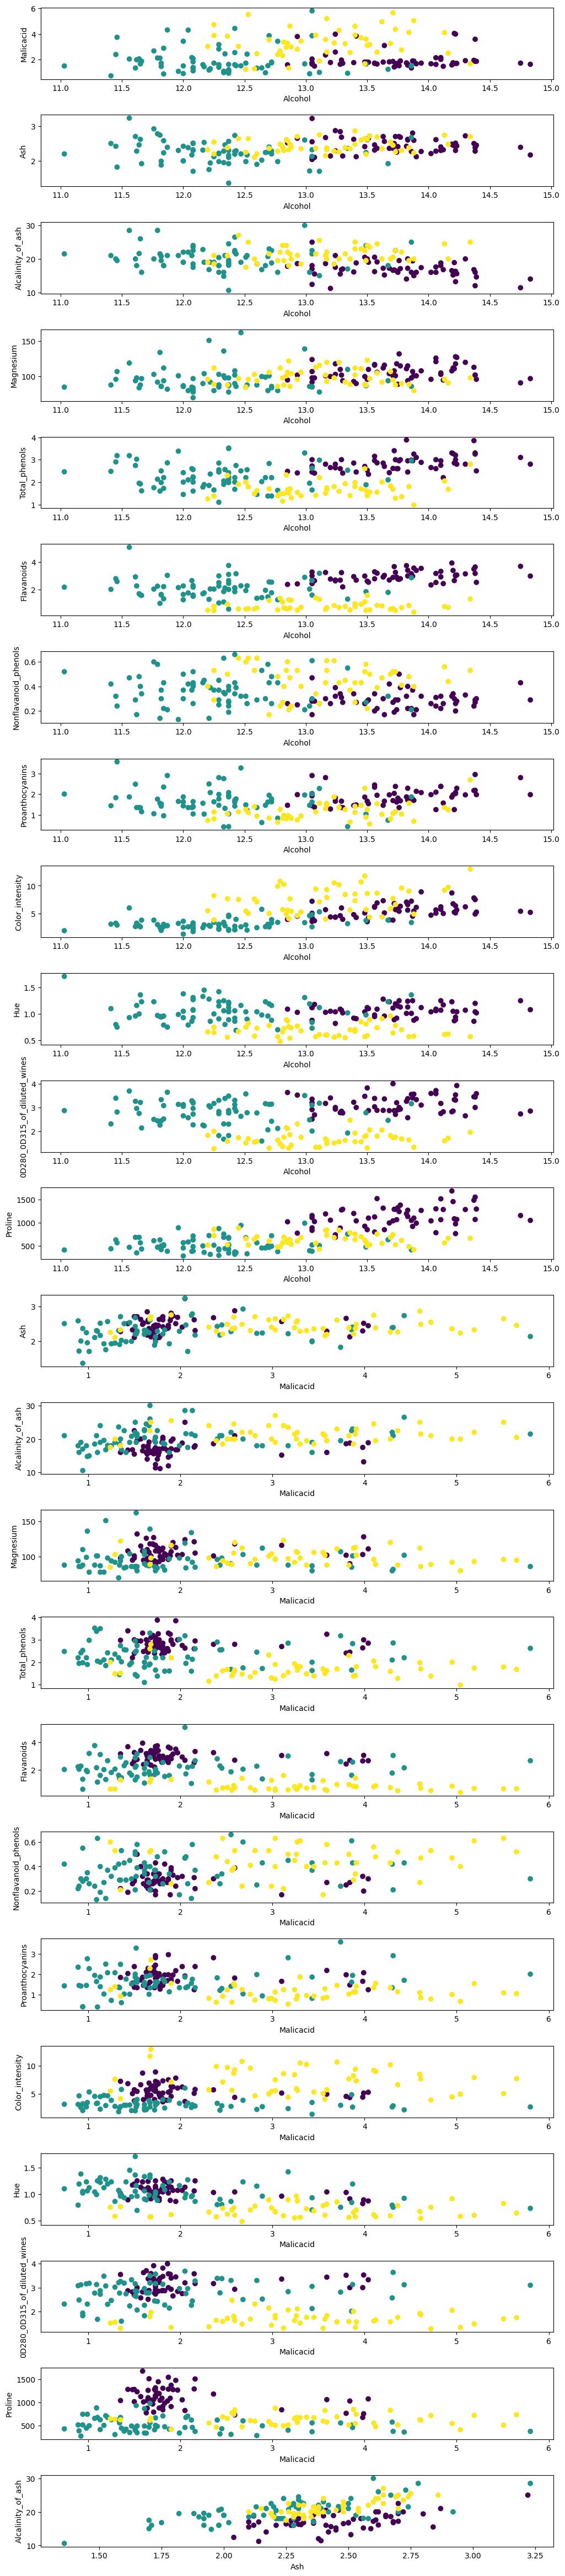

In [43]:
combinations_wine = list(itertools.combinations(X_wine.columns, 2))
# Y_wine is already a NumPy array, no need to convert
# Y_wine = Y_wine.to_numpy()  

plt.figure(figsize=(12, 48))  # Taller figure for vertical stacking
for i in range(24):
    plt.subplot(24, 1, i+1)  # 24 rows, 1 column
    plt.scatter(
        X_wine[combinations_wine[i][0]],
        X_wine[combinations_wine[i][1]],
        c=Y_wine_encoded
    )
    plt.subplots_adjust(top=0.98, bottom=0.02, hspace=0.5)
    plt.xlabel(combinations_wine[i][0])
    plt.ylabel(combinations_wine[i][1])

plt.show()


In [44]:
X_train_wine, X_test_wine, Y_train_wine, Y_test_wine = train_test_split(
    X_wine, Y_wine, test_size=0.15, random_state=42
)

In [45]:

wine_classifier=KNN(X_train_wine,Y_train_wine)

6


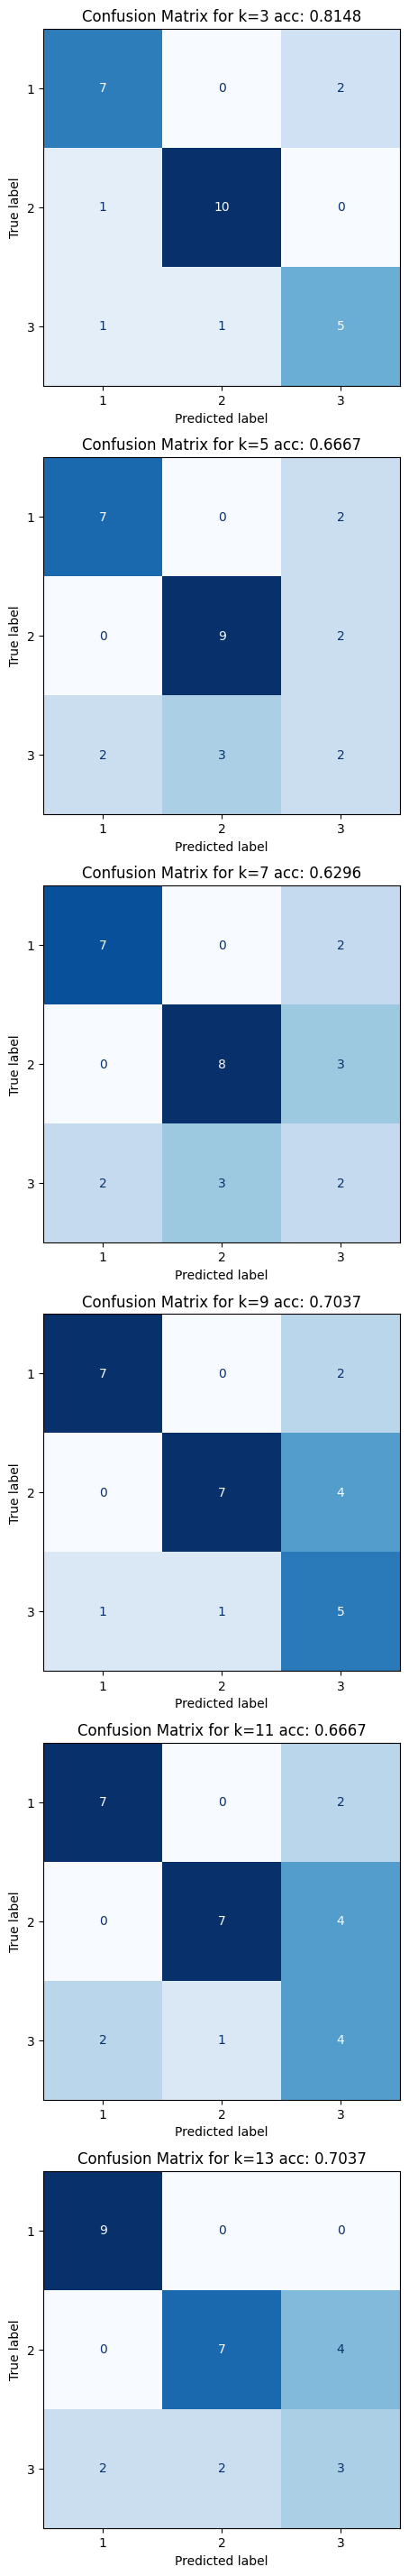

In [47]:
ks=[3,5,7,9,11,13]

fig, axes = plt.subplots(len(ks), 1, figsize=(12, 36))

accuracies_wine=[]
for i,k in enumerate(ks):

    plt.subplot(len(ks),1,i+1)
    predictions_wine=wine_classifier.predict(X_test_wine,k)
    cm_wine=confusion_matrix(Y_test_wine,predictions_wine)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_wine, display_labels=le_wine.classes_)
    disp.plot(cmap="Blues", values_format="d", ax=axes[i], colorbar=False)
    # print(predictions_wine)
    # print(Y_test_wine)
    acc = (predictions_wine == Y_test_wine.values.flatten()).sum() / Y_test_wine.shape[0]
    axes[i].set_title(f"Confusion Matrix for k={k} acc: {acc:.4f}")
    accuracies_wine.append(acc)
print(len(accuracies_wine))
plt.show()

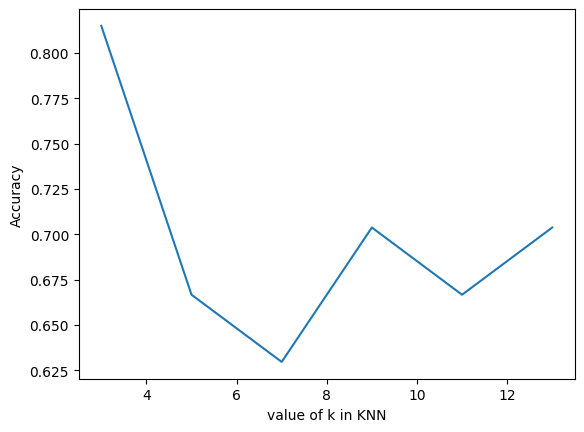

In [48]:
plt.plot(ks,accuracies_wine)
plt.xlabel("value of k in KNN")
plt.ylabel("Accuracy")
plt.show()